# CSDA summary of multi-spec imagery

Paul Montesano, PhD  
August 2025

In [ ]:
install.packages("DT")

In [ ]:
install.packages("kableExtra")

In [114]:
library(tidyverse)
library(lubridate)
library(RColorBrewer)
library(googlesheets4)
library(ggrepel)
library(knitr)

In [70]:
library(DT)
library(kableExtra)
library(IRdisplay)

ERROR: Error in library(kableExtra): there is no package called ‘kableExtra’


In [115]:
# Authenticate
gs4_deauth()

In [116]:
# # sheet_id = 'Specs'
# # spreadsheet_id = '13MrpqFtAOqQY9WdW9lHNsqjCbG-e3VQkEDbHOGIKa6k'
# # url = f'https://docs.google.com/spreadsheets/d/{spreadsheet_id}/export?format=csv&gid={sheet_id}'
# url = '/projects/my-private-bucket/databank/csda/NASA CSDA Multi-Spectral Sensor Platform Metadata - Vendor Specs.csv'

In [117]:
#f = head(read.csv(url, skip = 2),10)

In [204]:
sheet_id = '13MrpqFtAOqQY9WdW9lHNsqjCbG-e3VQkEDbHOGIKa6k'
df = read_sheet(sheet_id, sheet = 'Vendor Specs', skip = 0) %>% 
    as.data.frame() %>%
    mutate(Constellation = ifelse(is.na(`Constellation/Platform`), ' ', `Constellation/Platform`)) %>%
    mutate(`Branded Name` = ifelse(is.na(`Branded Name`), ' ', `Branded Name`)) %>%
    # Convert TIR columns from µm to nm (multiply by 1000)
    mutate(
        `TIRLWIR1 Min (nm)` = `TIRLWIR1 Min (µm)` * 1000,
        `TIRLWIR1 Max (nm)` = `TIRLWIR1 Max (µm)` * 1000,
        `TIRLWIR2 Min (nm)` = `TIRLWIR2 Min (µm)` * 1000,
        `TIRLWIR2 Max (nm)` = `TIRLWIR2 Max (µm)` * 1000
    )

✔ Reading from CSDA Prototype Vendor Specifications & Evaluation DB.

✔ Range ''Vendor Specs''.



In [205]:
names(df)

[1] "Sensor/Generation"           "Constellation/Platform"     
 [3] "Launch Date"                 "End Date"                   
 [5] "Branded Name"                "Reference"                  
 [7] "Affiliation"                 "Sector"                     
 [9] "Mission Status"              "Satellite Size Class"       
[11] "Weight Range (kg)"           "Orbit Type"                 
[13] "Orbit Altitude (km)"         "Orbit Period (min)"         
[15] "Revisit Time (days)"         "Swath Width (km)"           
[17] "Scanner Type"                "Acquisition Strategy"       
[19] "n satellites"                "assessment status"          
[21] "Pan GSD Nadir (m)"           "MS GSD Nadir (m)"           
[23] "SWIR GSD Nadir (m)"          "TIR GSD Nadir (m)"          
[25] "Pan GSD Off-Nadir Min (m)"   "Pan GSD Off-Nadir Max (m)"  
[27] "MS GSD Off-Nadir Min (m)"    "MS GSD Off-Nadir Max (m)"   
[29] "Geolocation Accuracy (CE90)" "Agility (off-nadir)"        
[31] "Stereo Capability"           "DEM Generation"             
[33] "Bit Depth"                   "Radiometric Resolution"     
[35] "SNR (Pan/MS)"                "Dynamic Range"              
[37] "Calibration Accuracy"        "Sharpness (MTF)"            
[39] "Pan Min (nm)"                "Pan Max (nm)"               
[41] "Coastal Min (nm)"            "Coastal Max (nm)"           
[43] "Blue Min (nm)"               "Blue Max (nm)"              
[45] "Blue2 Min (nm)"              "Blue2 Max (nm)"             
[47] "Green1 Min (nm)"             "Green1 Max (nm)"            
[49] "Green2 Min (nm)"             "Green2 Max (nm)"            
[51] "Yellow Min (nm)"             "Yellow Max (nm)"            
[53] "Red Min (nm)"                "Red Max (nm)"               
[55] "RedEdge Min (nm)"            "RedEdge Max (nm)"           
[57] "RedEdge1 Min (nm)"           "RedEdge1 Max (nm)"          
[59] "RedEdge2 Min (nm)"           "RedEdge2 Max (nm)"          
[61] "NIR Min (nm)"                "NIR Max (nm)"               
[63] "NIR2 Min (nm)"               "NIR2 Max (nm)"              
[65] "NIR WV Min (nm)"             "NIR WV Max (nm)"            
[67] "SWIRCirrus Min (nm)"         "SWIRCirrus Max (nm)"        
[69] "SWIR1 Min (nm)"              "SWIR1 Max (nm)"             
[71] "SWIR2 Min (nm)"              "SWIR2 Max (nm)"             
[73] "TIRLWIR1 Min (µm)"           "TIRLWIR1 Max (µm)"          
[75] "TIRLWIR2 Min (µm)"           "TIRLWIR2 Max (µm)"          
[77] "Total Bands (MS)"            "Total Bands"                
[79] "Notes"                       "Constellation"              
[81] "TIRLWIR1 Min (nm)"           "TIRLWIR1 Max (nm)"          
[83] "TIRLWIR2 Min (nm)"           "TIRLWIR2 Max (nm)"

In [206]:
names(df)[c(1:10, 45:53)]

[1] "Sensor/Generation"      "Constellation/Platform" "Launch Date"           
 [4] "End Date"               "Branded Name"           "Reference"             
 [7] "Affiliation"            "Sector"                 "Mission Status"        
[10] "Satellite Size Class"   "Blue2 Min (nm)"         "Blue2 Max (nm)"        
[13] "Green1 Min (nm)"        "Green1 Max (nm)"        "Green2 Min (nm)"       
[16] "Green2 Max (nm)"        "Yellow Min (nm)"        "Yellow Max (nm)"       
[19] "Red Min (nm)"

In [207]:
# Create the summarized table

summary_table <- df %>%
  # Combine Sensor/Generation and Constellation
  mutate(`Constellation/Sensor` = paste(`Constellation`,`Sensor/Generation`, sep = " - ")) %>%
  # Select the columns we want to summarize
  select(`Constellation/Sensor`, `Affiliation`, `Sector`, `Launch Date`, `End Date`,
         `Revisit Time (days)`, 
         `Swath Width (km)`, 
         `Scanner Type`,
         `MS GSD Nadir (m)`,
        # `Collection Strategy`, 
         #`Mission Status`, 
         `n satellites`, `Geolocation Accuracy (CE90)`,`Agility (off-nadir)`,`Stereo Capability`,`Radiometric Resolution`,
         #`Calibration Accuracy`,
         `Sharpness (MTF)`,
         `Total Bands (MS)`, `Total Bands`) %>%
  # mutate(
  #   `Launch Date` = as.character(`Launch Date`),
  #   `End Date` = as.character(`End Date`)
  # ) %>%
  # Remove any duplicate rows if needed
  distinct() %>%
  mutate(across(c(`MS GSD Nadir (m)`,`Total Bands (MS)`), as.character)) %>%
  mutate(across(c(`MS GSD Nadir (m)`,`Total Bands (MS)`), ~replace_na(., ""))) %>%
  mutate(across(where(is.character), ~replace_na(., " ")))# %>%
  #mutate(across(where(is.numeric), ~replace_na(., -Inf)))


# To get it as markdown, you can use knitr::kable()
library(knitr)
markdown_table <- kable(summary_table, format = "markdown")

# Design the custom summary table
## `You'll want to change this every time you run this notebook`

In [239]:
# Define your custom order (replace with your desired order)
custom_order_affiliation_list <- c('US Agency','ESA','Airbus','Satellogic','BlackSky','Planet Labs','Maxar','EarthDaily')

# Define the platforms that you dont want to see (easier than specifying what you DO want to see?)
#custom_remove_platform_list <- c('SkySat','Pelican') # TODO --- work this in below
custom_remove_platform_list <- c('Pelican')
custom_remove_platform_regex <- paste0(custom_remove_platform_list, collapse = "|")

In [240]:
summary_table_subset = summary_table %>% 
                filter(`Affiliation` %in% custom_order_affiliation_list) %>%
                filter(!grepl(custom_remove_platform_regex, `Constellation/Sensor`)) %>% 
                filter( (Affiliation == 'Planet Labs') 
                       | (Affiliation == 'Maxar')
                       | (Affiliation == 'Airbus')
                       | (Affiliation == 'EarthDaily')
                       | (Affiliation == 'Satellogic')
                      ) %>% 
                filter(!grepl("Tanager", `Constellation/Sensor`)) %>% 
                # filter(
                #     Affiliation != 'Maxar' | 
                #     (Affiliation == 'Maxar' & 
                #      str_detect(`Constellation/Sensor`, "WorldView-[23]|WV0[23]"))
                #   ) %>%
                droplevels()
dim(summary_table_subset)

[1] 32 17

In [241]:
colnames(summary_table_subset)

[1] "Constellation/Sensor"        "Affiliation"                
 [3] "Sector"                      "Launch Date"                
 [5] "End Date"                    "Revisit Time (days)"        
 [7] "Swath Width (km)"            "Scanner Type"               
 [9] "MS GSD Nadir (m)"            "n satellites"               
[11] "Geolocation Accuracy (CE90)" "Agility (off-nadir)"        
[13] "Stereo Capability"           "Radiometric Resolution"     
[15] "Sharpness (MTF)"             "Total Bands (MS)"           
[17] "Total Bands"

In [242]:

# Pivot the data frame
pivoted_summary_table <- summary_table_subset %>%
  mutate(across(c(`Constellation/Sensor`, `Affiliation`, `Sector`, `Launch Date`, `End Date`,
         `Revisit Time (days)`, 
         `Swath Width (km)`, 
         `Scanner Type`,
         `MS GSD Nadir (m)`,
         `n satellites`, `Geolocation Accuracy (CE90)`,`Agility (off-nadir)`,`Stereo Capability`,`Radiometric Resolution`,
                  #`Calibration Accuracy`,
                  `Sharpness (MTF)`,
         `Total Bands (MS)`, `Total Bands`), 
                as.character)) %>%
  pivot_longer(
    cols = c( 
       `Sector`,
        `Affiliation`,`Launch Date`, `End Date`,
         `Revisit Time (days)`, 
         `Swath Width (km)`, 
         `Scanner Type`,
         `MS GSD Nadir (m)`,
         `n satellites`, `Geolocation Accuracy (CE90)`,`Agility (off-nadir)`,`Stereo Capability`,`Radiometric Resolution`,
        #`Calibration Accuracy`,
        `Sharpness (MTF)`,
         `Total Bands (MS)`, `Total Bands`),
    names_to = "Vendor Specifications",
    values_to = "temp_value"
  ) %>%
  pivot_wider(
    names_from = `Constellation/Sensor`,
    values_from = temp_value
  )

# FIXED: Create sensor order based on parent company order
# Get the parent company for each sensor
parent_company_mapping <- pivoted_summary_table %>%
  filter(`Vendor Specifications` == "Affiliation") %>%
  select(-`Vendor Specifications`) %>%
  pivot_longer(everything(), names_to = "sensor", values_to = "company")

# Order sensors by parent company according to custom_order_affiliation_list
ordered_sensors <- parent_company_mapping %>%
  mutate(company = factor(company, levels = custom_order_affiliation_list)) %>%
  arrange(company) %>%
  pull(sensor)

# Reorder columns
pivoted_summary_table <- pivoted_summary_table %>%
  select(`Vendor Specifications`, all_of(ordered_sensors))

# Get parent company values for each column (excluding 'Vendor Specifications' column)
parent_companies <- pivoted_summary_table %>%
  filter(`Vendor Specifications` == "Affiliation") %>%
  select(-`Vendor Specifications`) %>%
  unlist()
    
pivoted_summary_table_html = pivoted_summary_table %>%
  kable(format = "html") %>%
  kable_styling() %>%
  row_spec(0, background = "darkgray")

# # Color each column based on parent company
# for(i in 1:length(parent_companies)) {
#   company <- parent_companies[i]
#   if(company %in% names(company_colors)) {
#     pivoted_summary_table_html <- pivoted_summary_table_html %>%
#       column_spec(i + 1, background = company_colors[company])  # i+1 because first col is 'Specs'
#   }
# }

# pivoted_summary_table_html = pivoted_summary_table_html %>%
#   column_spec(c(2,3,4), background = "#2b8cbe")

display_html(as.character(pivoted_summary_table_html))

ERROR: Error in row_spec(., 0, background = "darkgray"): could not find function "row_spec"


In [243]:
parent_companies

Pleiades Neo - Neo 3       Pleiades Neo - Neo 4 
                  "Airbus"                   "Airbus" 
          Pleiades - PHR1A           Pleiades - PHR1B 
                  "Airbus"                   "Airbus" 
              SPOT - SPOT6               SPOT - SPOT7 
                  "Airbus"                   "Airbus" 
           NewSat - Mark I           NewSat - Mark II 
              "Satellogic"               "Satellogic" 
         NewSat - Mark III           NewSat - Mark IV 
              "Satellogic"               "Satellogic" 
           NewSat - Mark V           RapidEye - 1 - 5 
              "Satellogic"              "Planet Labs" 
              SkySat - A/B                SkySat - C1 
             "Planet Labs"              "Planet Labs" 
               SkySat - C2 PlanetScope - Dove-Classic 
             "Planet Labs"              "Planet Labs" 
      PlanetScope - Dove-R    PlanetScope - SuperDove 
             "Planet Labs"              "Planet Labs" 
          MAXAR - GeoEye-1             MAXAR - IKONOS 
                   "Maxar"                    "Maxar" 
          Maxar - Legion-1           Maxar - Legion-2 
                   "Maxar"                    "Maxar" 
          Maxar - Legion-3           Maxar - Legion-4 
                   "Maxar"                    "Maxar" 
          Maxar - Legion-5           Maxar - Legion-6 
                   "Maxar"                    "Maxar" 
       MAXAR - QuickBird-2        MAXAR - WorldView-1 
                   "Maxar"                    "Maxar" 
       MAXAR - WorldView-2        MAXAR - WorldView-3 
                   "Maxar"                    "Maxar" 
       MAXAR - WorldView-4    EarthDaily Aurora - EDA 
                   "Maxar"               "EarthDaily"

In [244]:
datatable(summary_table)

HTML widgets cannot be represented in plain text (need html)

In [245]:
levels(factor(df$`Affiliation`))

[1] "Airbus"      "BlackSky"    "EarthDaily"  "ESA"         "HydroSat"   
 [6] "JAXA"        "Maxar"       "Planet Labs" "Satellogic"  "SatVu"      
[11] "US Agency"

## Tables

#### Satellite size classes

| Size Class | Mass Range (kg) | Typical Examples |
|------------|----------------|------------------|
| **Large** | > 1,000 | Geostationary communication satellites, large Earth observation satellites |
| **Medium** | 500 - 1,000 | Regional communication satellites, some scientific missions |
| **Mini** | 100 - 500 | Small Earth observation satellites, technology demonstrators |
| **Micro** | 10 - 100 | University research satellites, constellation satellites |
| **Nano** | 1 - 10 | CubeSats (1U-6U typically), educational satellites |

**Additional Notes:**
- **Pico** satellites (0.1 - 1 kg) and **Femto** satellites (< 0.1 kg) are sometimes used for even smaller classifications
- CubeSats are a popular standard within the nano class, with 1U ≈ 1.33 kg, 3U ≈ 4 kg, 6U ≈ 8 kg
- These classifications can vary slightly between different organizations and applications
- The boundaries between classes are not universally standardized and may differ in some contexts

## Plots

In [246]:
library(RColorBrewer)

create_advanced_combined_palette <- function(df, column, 
                                           palette_config = list(
                                             list(palette = "Set1", weight = 0.5),
                                             list(palette = "Set2", weight = 0.5)
                                           ),
                                           method = "weighted",
                                           override_colors = NULL) {
  # Extract the column as factor
  factor_col <- as.factor(df[[column]])
  unique_levels <- levels(factor_col)
  n_levels <- length(unique_levels)
  
  # First handle automatic palette generation
  if (method == "weighted") {
    # Calculate how many colors to take from each palette based on weights
    weights <- sapply(palette_config, function(x) x$weight)
    weights <- weights / sum(weights)  # Normalize weights
    
    n_colors <- round(n_levels * weights)
    n_colors[length(n_colors)] <- n_levels - sum(n_colors[-length(n_colors)])  # Adjust last to sum to total
    
    all_colors <- character(0)
    
    for (i in seq_along(palette_config)) {
      if (n_colors[i] > 0) {
        palette_name <- palette_config[[i]]$palette
        max_colors <- brewer.pal.info[palette_name, "maxcolors"]
        
        if (n_colors[i] <= max_colors) {
          pal_colors <- brewer.pal(max(3, n_colors[i]), palette_name)[1:n_colors[i]]
        } else {
          base_colors <- brewer.pal(max_colors, palette_name)
          pal_colors <- colorRampPalette(base_colors)(n_colors[i])
        }
        
        all_colors <- c(all_colors, pal_colors)
      }
    }
    
    colors <- all_colors[1:n_levels]
  } else {
    # Default to a single palette if method not recognized
    if (n_levels <= 9) {
      colors <- brewer.pal(max(3, n_levels), palette_config[[1]]$palette)[1:n_levels]
    } else {
      max_colors <- brewer.pal.info[palette_config[[1]]$palette, "maxcolors"]
      base_colors <- brewer.pal(max_colors, palette_config[[1]]$palette)
      colors <- colorRampPalette(base_colors)(n_levels)
    }
  }
  
  # Create initial named vector
  color_dict <- setNames(colors, unique_levels)
  
  # Apply override colors if provided
  if (!is.null(override_colors)) {
    # Check which override levels exist in our factor levels
    valid_overrides <- names(override_colors)[names(override_colors) %in% unique_levels]
    
    # Apply valid overrides
    for (level in valid_overrides) {
      color_dict[level] <- override_colors[level]
    }
    
    # Optionally warn about invalid overrides
    invalid_overrides <- names(override_colors)[!names(override_colors) %in% unique_levels]
    if (length(invalid_overrides) > 0) {
      warning(paste("The following override levels were not found in the data:", 
                    paste(invalid_overrides, collapse=", ")))
    }
  }
  
  return(color_dict)
}

# Example with sequential method too
create_combined_color_dict <- function(df, column, palette1 = "Set1", palette2 = "Set2", 
                                      split_point = NULL, method = "sequential",
                                      override_colors = NULL) {
  # Extract the column as factor
  factor_col <- as.factor(df[[column]])
  unique_levels <- levels(factor_col)
  n_levels <- length(unique_levels)
  
  # Determine split point if not provided
  if (is.null(split_point)) {
    split_point <- ceiling(n_levels / 2)
  }
  
  # Ensure split_point is within valid range
  split_point <- max(1, min(split_point, n_levels - 1))
  
  # Method 1: Sequential - first palette for first part, second for second part
  if (method == "sequential") {
    # Colors from first palette
    n1 <- split_point
    if (n1 <= 3) {
      colors1 <- brewer.pal(max(3, n1), palette1)[1:n1]
    } else if (n1 <= brewer.pal.info[palette1, "maxcolors"]) {
      colors1 <- brewer.pal(n1, palette1)
    } else {
      colors1 <- colorRampPalette(brewer.pal(brewer.pal.info[palette1, "maxcolors"], palette1))(n1)
    }
    
    # Colors from second palette
    n2 <- n_levels - split_point
    if (n2 > 0) {
      if (n2 <= 3) {
        colors2 <- brewer.pal(max(3, n2), palette2)[1:n2]
      } else if (n2 <= brewer.pal.info[palette2, "maxcolors"]) {
        colors2 <- brewer.pal(n2, palette2)
      } else {
        colors2 <- colorRampPalette(brewer.pal(brewer.pal.info[palette2, "maxcolors"], palette2))(n2)
      }
      colors <- c(colors1, colors2)
    } else {
      colors <- colors1
    }
  }
  
  # Other methods would go here (interleaved, blended, etc.)
  # ...
  
  # Create initial color dictionary
  color_dict <- setNames(colors[1:n_levels], unique_levels)
  
  # Apply override colors if provided
  if (!is.null(override_colors)) {
    # Check which override levels exist in our factor levels
    valid_overrides <- names(override_colors)[names(override_colors) %in% unique_levels]
    
    # Apply valid overrides
    for (level in valid_overrides) {
      color_dict[level] <- override_colors[level]
    }
    
    # Optionally warn about invalid overrides
    invalid_overrides <- names(override_colors)[!names(override_colors) %in% unique_levels]
    if (length(invalid_overrides) > 0) {
      warning(paste("The following override levels were not found in the data:", 
                    paste(invalid_overrides, collapse=", ")))
    }
  }
  
  return(color_dict)
}
                      create_color_dict <- function(df, column, palette = "Set1") {
  # Extract the column as factor
  factor_col <- as.factor(df[[column]])
  unique_levels <- levels(factor_col)
  n_levels <- length(unique_levels)
  
  # Handle case where we need more colors than palette provides
  if (n_levels <= 3) {
    colors <- brewer.pal(max(3, n_levels), palette)[1:n_levels]
  } else if (n_levels <= brewer.pal.info[palette, "maxcolors"]) {
    colors <- brewer.pal(n_levels, palette)
  } else {
    # Use colorRampPalette for more colors
    colors <- colorRampPalette(brewer.pal(brewer.pal.info[palette, "maxcolors"], palette))(n_levels)
  }
  
  # Create named vector (dictionary)
  color_dict <- setNames(colors, unique_levels)
  
  return(color_dict)
}

In [247]:
CAPTION_TEXT = 'Montesano, Nickeson NASA GSFC'
MAIN_TITLE = 'Summary of commercial multi-spectral satellite specifications'

In [248]:
# Usage
color_dict <- create_color_dict(df, "Affiliation", "Set1")
color_dict <- create_advanced_combined_palette(df, "Affiliation")
# Example 1: Using the weighted method with overrides
color_dict <- create_advanced_combined_palette(
  df, "Affiliation", 
  palette_config = list(
    list(palette = "Set1", weight = 0.5),
    list(palette = "Dark2", weight = 0.5)
  ),
  override_colors = c('BlackSky' = 'black', 'US Agency' = 'blue')
)

In [249]:
color_dict

Airbus    BlackSky  EarthDaily         ESA    HydroSat        JAXA 
  "#E41A1C"     "black"   "#4DAF4A"   "#984EA3"   "#FF7F00"   "#FFFF33" 
      Maxar Planet Labs  Satellogic       SatVu   US Agency 
  "#1B9E77"   "#D95F02"   "#7570B3"   "#E7298A"      "blue"

In [265]:
# Create a dataset with one label per unique position
df_unique_labels <- summary_table_subset %>%
  group_by(`Constellation/Sensor`,`Swath Width (km)`, `MS GSD Nadir (m)`) %>%
  slice(1) %>%  # Take first row from each group
  ungroup()
df_unique_labels

ERROR while rich displaying an object: Error in (function (..., row.names = NULL, check.rows = FALSE, check.names = TRUE, : arguments imply differing number of rows: 1, 0

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         re

Warning message in geom_text_repel(aes(label = paste0(`Constellation/Sensor`)), :
“Ignoring unknown parameters: `fill`”
Warning message:
“ggrepel: 2 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


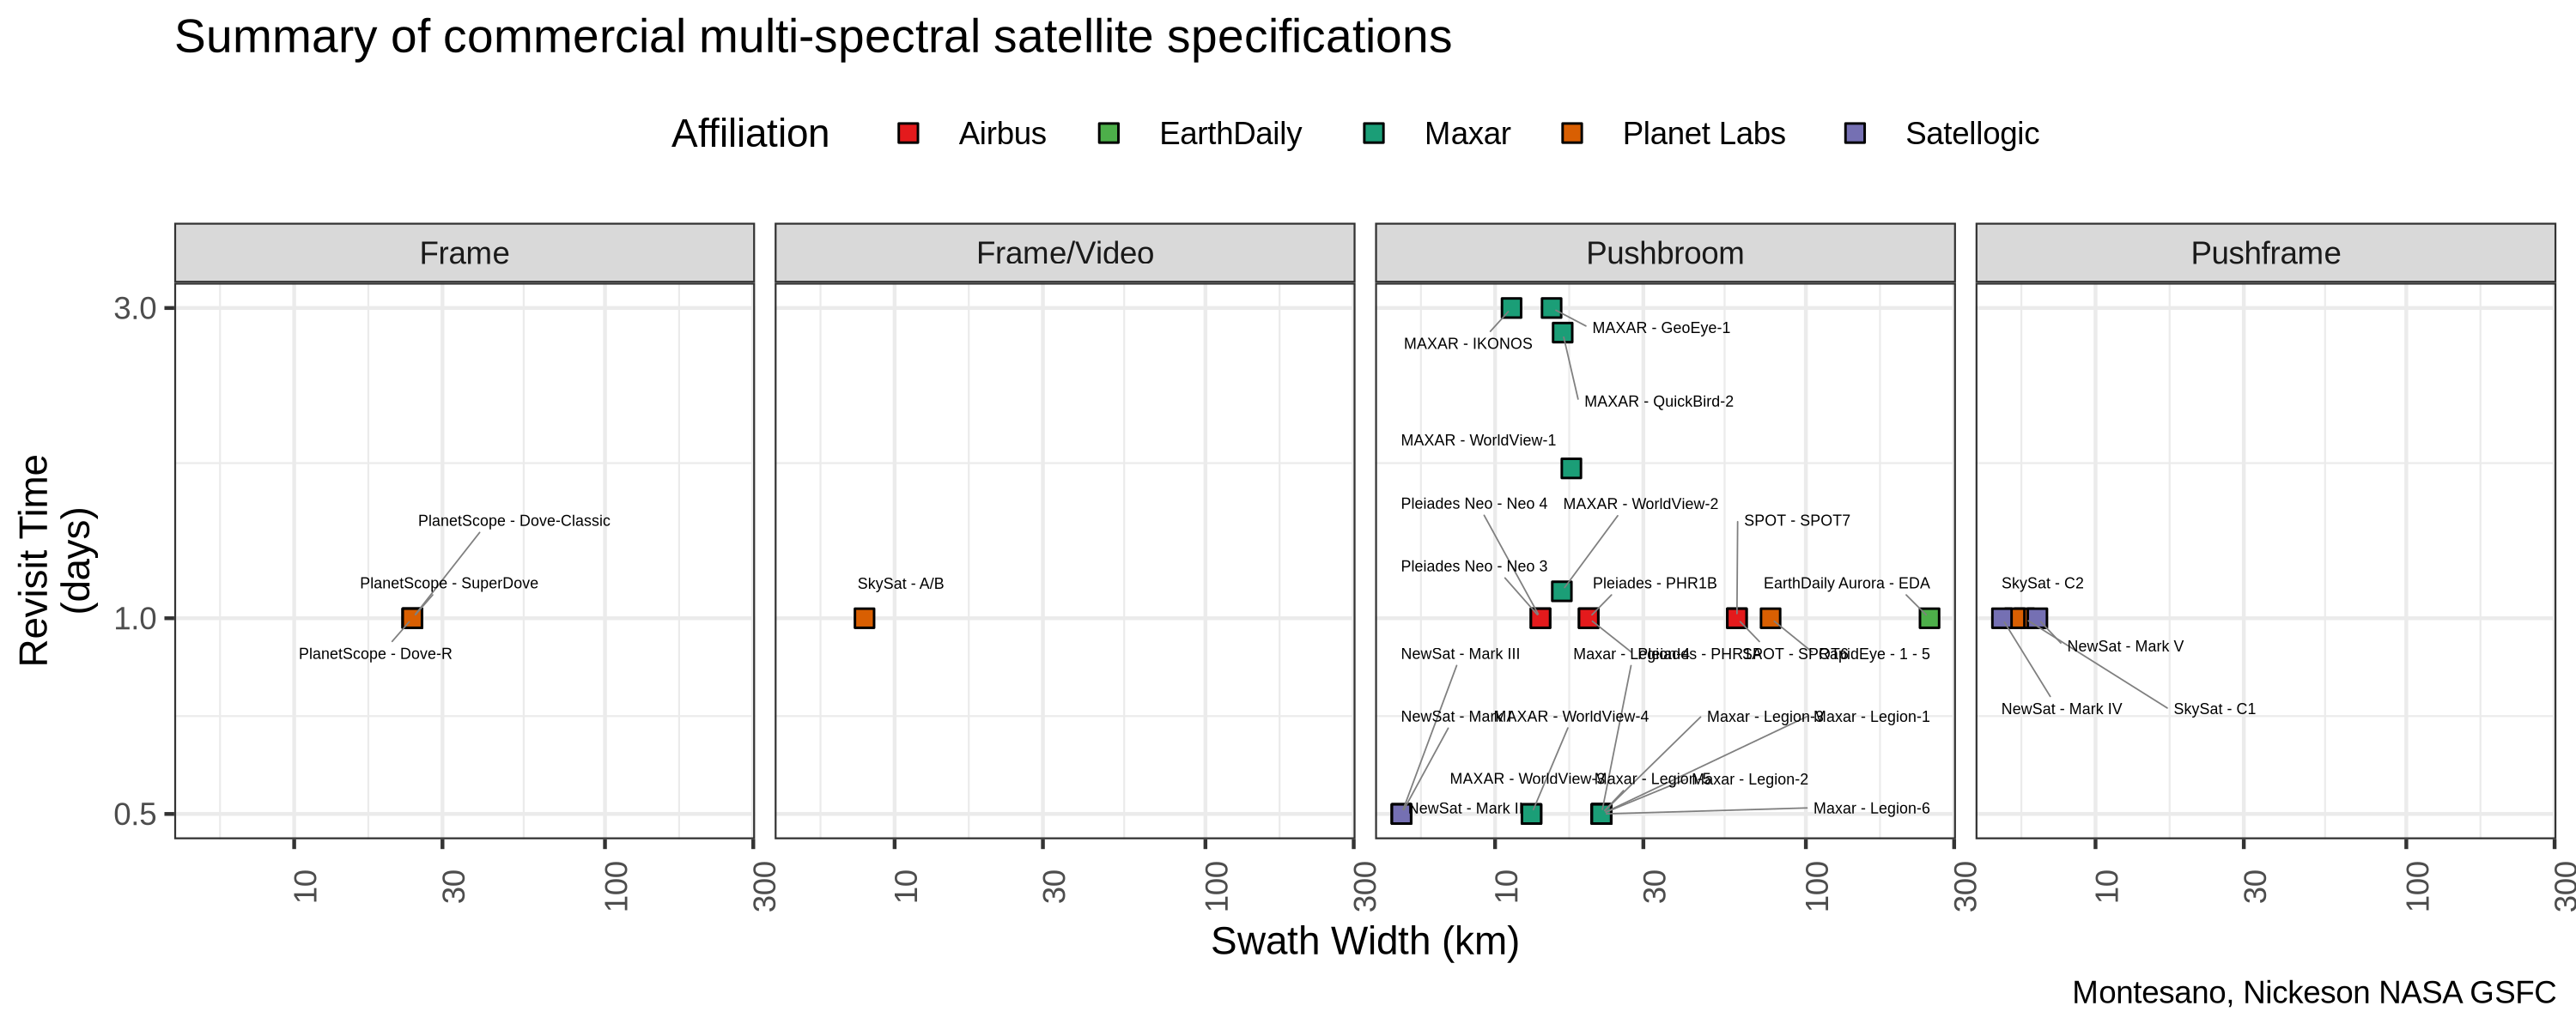

In [266]:
options(repr.plot.width = 10, repr.plot.height = 4, repr.plot.res = 300)

# Create a dataset with one label per unique position
df_unique_labels <- summary_table_subset %>%
  group_by(`Constellation/Sensor`,`Swath Width (km)`, `MS GSD Nadir (m)`) %>%
  slice(1) %>%  # Take first row from each group
  ungroup()

ggplot(summary_table_subset , aes(x=`Swath Width (km)`, y=as.numeric(`Revisit Time (days)`), fill=`Affiliation`)) +
    geom_point(size=2.5, shape=22, color='black',alpha=1) +    
    geom_text_repel(
        #data = df_unique_labels,  # Use the filtered dataset for labels
        aes(label=paste0(`Constellation/Sensor`)), 
        size=1.5, color='black',
        show.legend = FALSE,
        box.padding = 0.5,
        point.padding = 0.03,
        segment.color = 'grey50',
        segment.size = 0.2,
        max.overlaps = 20, #Inf
        seed = 42, fill='NA', alpha=1
    ) +
    scale_fill_manual(values=color_dict) + #scale_color_manual(values=company_colors) +
    scale_x_log10() +
    scale_y_log10() +
    theme_bw() + 
    theme(axis.text.x = element_text(angle=90), legend.position = 'top') +
    facet_wrap(~`Scanner Type`, nrow=1) + labs(y = 'Revisit Time\n(days)'
                                           , caption=CAPTION_TEXT
                                          , title=MAIN_TITLE)
#facet_grid(`Satellite.Type`~`Scanner.Type`)

In [256]:
summary_table_subset 

Constellation/Sensor,Affiliation,Sector,Launch Date,End Date,Revisit Time (days),Swath Width (km),Scanner Type,MS GSD Nadir (m),n satellites,Geolocation Accuracy (CE90),Agility (off-nadir),Stereo Capability,Radiometric Resolution,Sharpness (MTF),Total Bands (MS),Total Bands
<chr>,<chr>,<chr>,<dttm>,<list>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
Pleiades Neo - Neo 3,Airbus,Commercial,2021-04-28,NULL,1.00,14.0,Pushbroom,1.2,1,<3m,±40°,Yes,12-bit,>0.30,6,6
Pleiades Neo - Neo 4,Airbus,Commercial,2021-08-16,NULL,1.00,14.0,Pushbroom,1.2,1,<3m,±40°,Yes,12-bit,>0.30,6,6
Pleiades - PHR1A,Airbus,Commercial,2011-12-17,NULL,1.00,20.0,Pushbroom,2,1,<3m,±47°,Yes,12-bit,>0.20,5,5
Pleiades - PHR1B,Airbus,Commercial,2012-12-02,NULL,1.00,20.0,Pushbroom,2,1,<3m,±47°,Yes,12-bit,>0.20,5,5
SPOT - SPOT6,Airbus,Commercial,2012-09-09,NULL,1.00,60.0,Pushbroom,6,1,<10m,±45°,Yes,12-bit,>0.15,5,5
SPOT - SPOT7,Airbus,Commercial,2014-06-30,1679011200,1.00,60.0,Pushbroom,6,1,<10m,±45°,Yes,12-bit,>0.15,5,5
EarthDaily Aurora - EDA,EarthDaily,Commercial,2025-06-25,Operational,1.00,250.0,Pushbroom,5,10,<10m,±45°,Yes,12-bit,>0.15,22,22
MAXAR - GeoEye-1,Maxar,Commercial,2008-09-06,NULL,3.00,15.2,Pushbroom,1.65,1,<3m,±60°,Yes,11-bit,>0.12,5,5
MAXAR - IKONOS,Maxar,Commercial,1999-09-24,1512086400,3.00,11.3,Pushbroom,3.28,1,<4m,±26°,Limited,11-bit,>0.10,5,5


Warning message in geom_text_repel(data = df_unique_labels, aes(label = paste0(`Constellation/Sensor`)), :
“Ignoring unknown parameters: `fill`”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


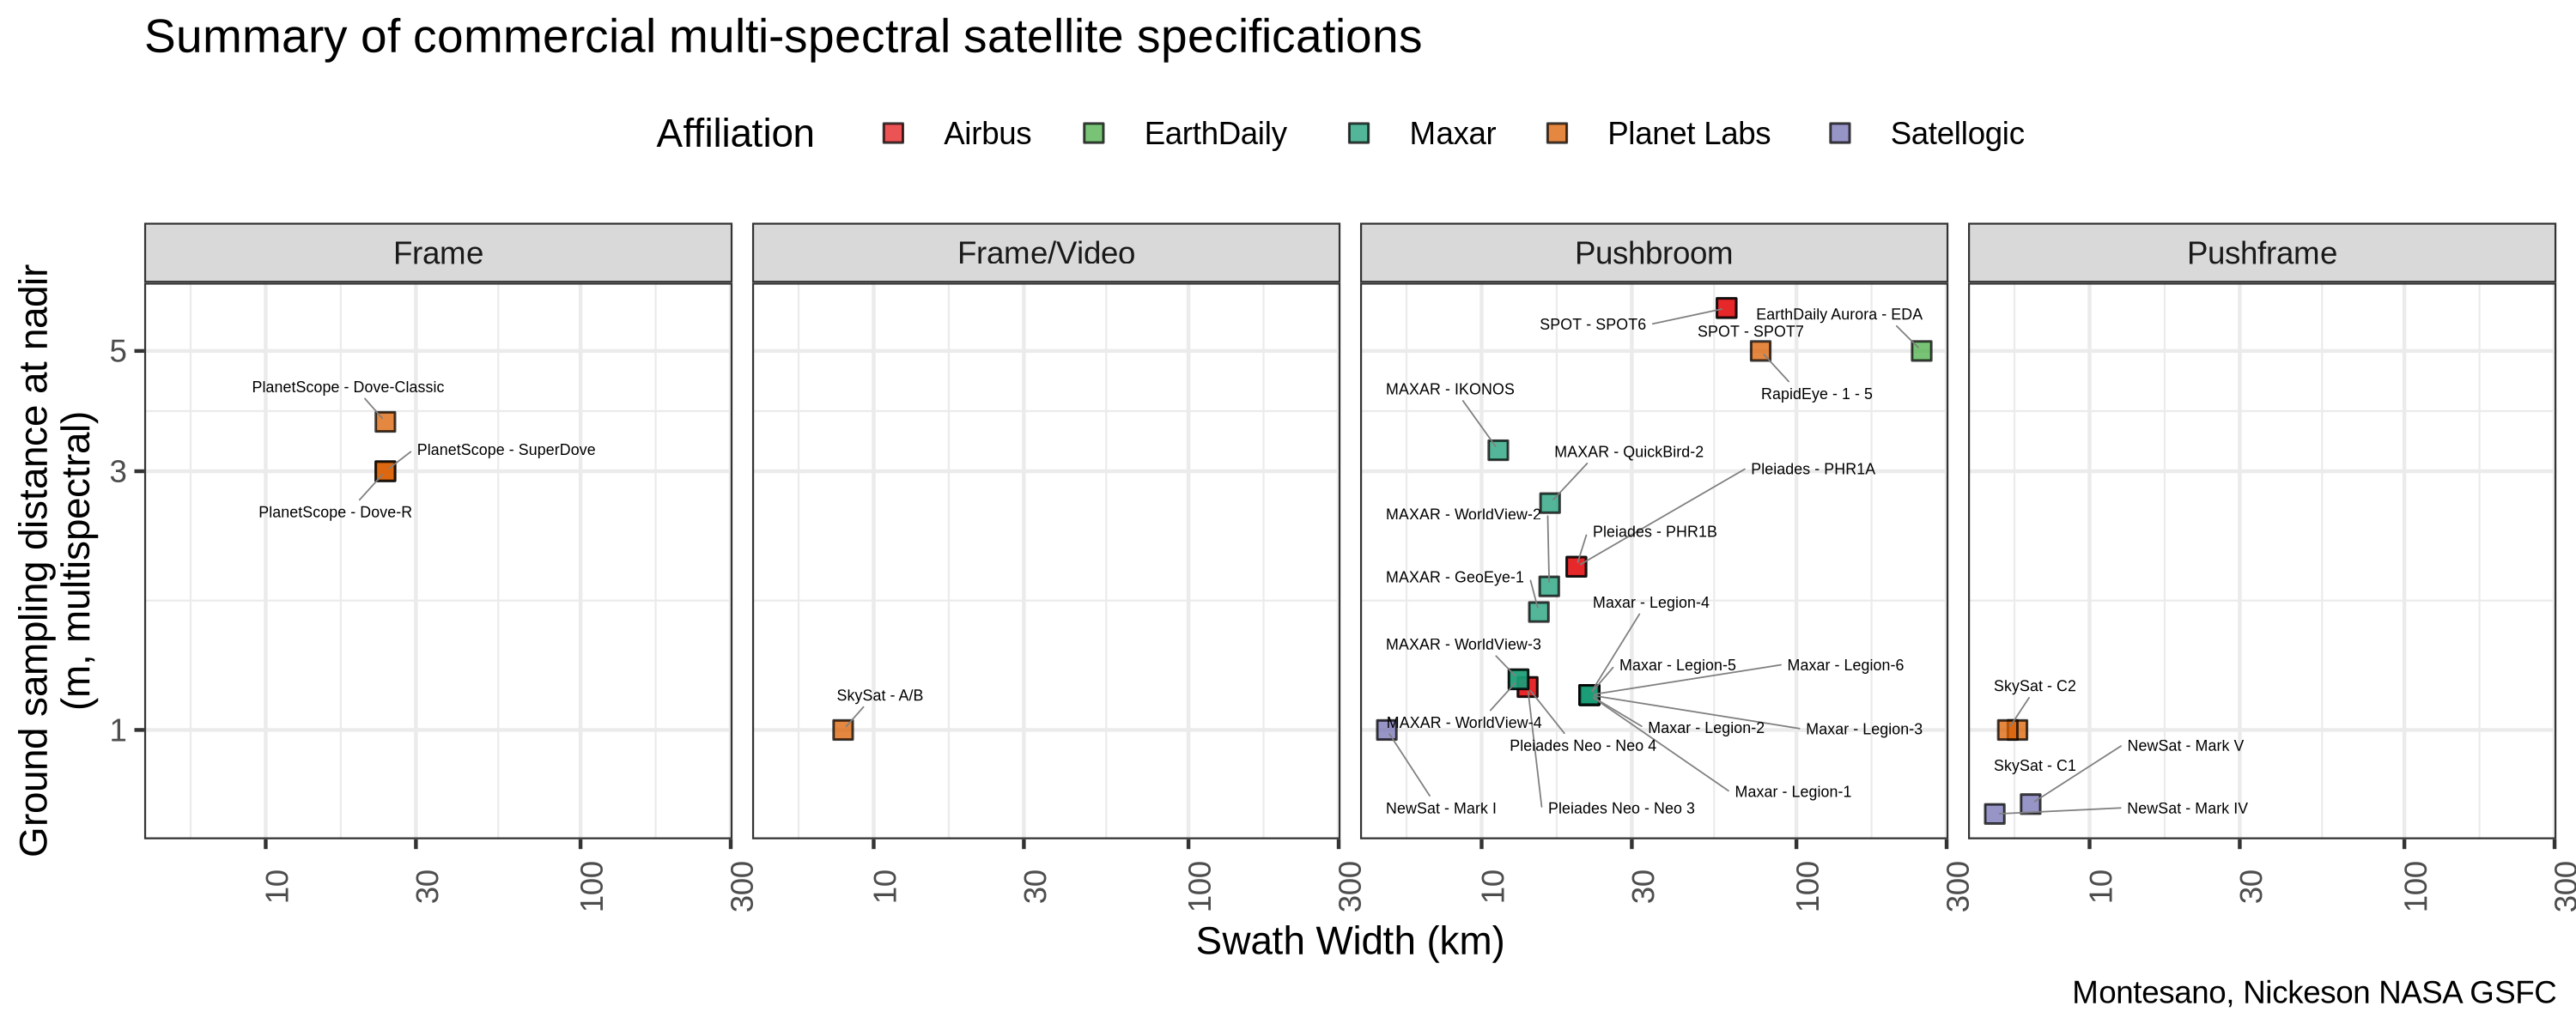

In [258]:
options(repr.plot.width = 10, repr.plot.height = 4, repr.plot.res = 300)

# # Create a dataset with one label per unique position
# df_unique_labels <- summary_table_subset %>%
#   group_by(`Constellation/Sensor`, `Swath Width (km)`, `MS GSD Nadir (m)`) %>%
#   slice(1) %>%  # Take first row from each group
#   ungroup()

ggplot(summary_table_subset, aes(x=`Swath Width (km)`, y=as.numeric(`MS GSD Nadir (m)`), fill=`Affiliation`)) +
    geom_point(size=2.5, shape=22, color='black',alpha=0.75) +    
    geom_text_repel(
        data = df_unique_labels,  # Use the filtered dataset for labels
        aes(label=paste0(`Constellation/Sensor`)), 
        size=1.5, color='black',
        show.legend = FALSE,
        box.padding = 0.5,
        point.padding = 0.03,
        segment.color = 'grey50',
        segment.size = 0.2,
        max.overlaps = Inf,
        seed = 42, fill='NA', alpha=1
    ) +
    scale_fill_manual(values=color_dict) + scale_color_manual(values=color_dict) +
    scale_x_log10() +
    scale_y_log10() +
    theme_bw() + 
    theme(axis.text.x = element_text(angle=90), legend.position = 'top') +
    facet_wrap(~`Scanner Type`, nrow=1) + labs(y = 'Ground sampling distance at nadir\n(m, multispectral)'
                                           , caption=CAPTION_TEXT
                                          , title=MAIN_TITLE)

Warning message in geom_text_repel(data = df_unique_labels, aes(label = paste0(`Constellation/Sensor`)), :
“Ignoring unknown parameters: `fill`”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


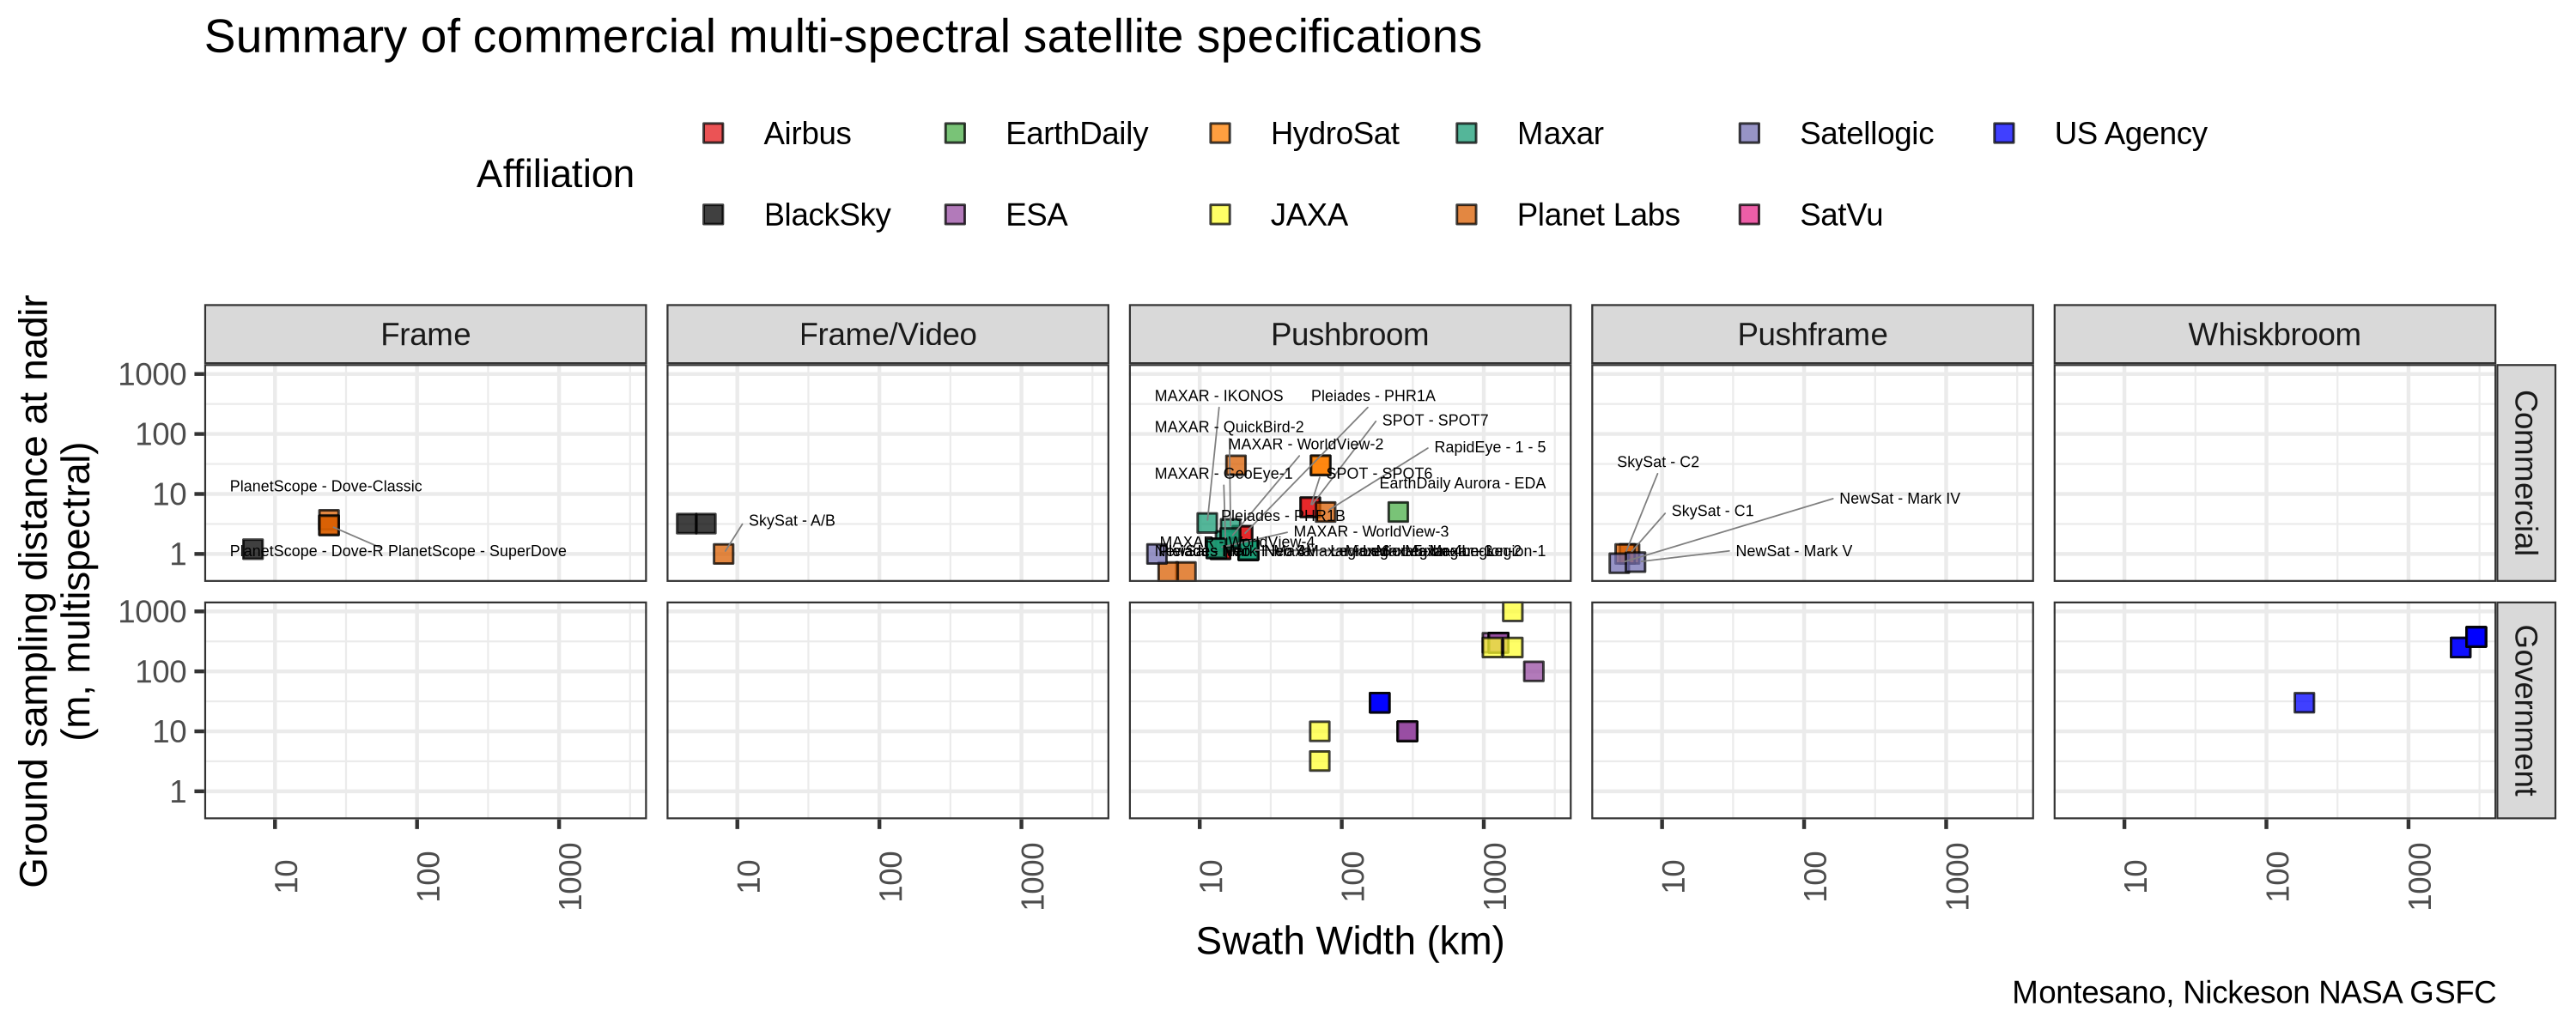

In [261]:
options(repr.plot.width = 10, repr.plot.height = 4, repr.plot.res = 300)

# # Create a dataset with one label per unique position
# df_unique_labels <- summary_table_subset %>%
#   group_by(`Constellation/Sensor`, `Swath Width (km)`, `MS GSD Nadir (m)`) %>%
#   slice(1) %>%  # Take first row from each group
#   ungroup()

ggplot(summary_table, aes(x=`Swath Width (km)`, y=as.numeric(`MS GSD Nadir (m)`), fill=`Affiliation`)) +
    geom_point(size=2.5, shape=22, color='black',alpha=0.75) +    
    geom_text_repel(
        data = df_unique_labels,
        aes(label=paste0(`Constellation/Sensor`)), 
        size=1.5, color='black',
        show.legend = FALSE,
        box.padding = 0.5,
        point.padding = 0.03,
        segment.color = 'grey50',
        segment.size = 0.2,
        max.overlaps = Inf,
        seed = 42, fill='NA', alpha=1
    ) +
    scale_fill_manual(values=color_dict) + 
    scale_color_manual(values=color_dict) +
    scale_x_log10() +
    scale_y_log10() +
    theme_bw() + 
    theme(
        axis.text.x = element_text(angle=90), 
        legend.position = 'top'
    ) +
    guides(fill = guide_legend(nrow = 2)) +  # Single row for legend
    facet_grid(Sector ~ `Scanner Type`) + 
    labs(
        y = 'Ground sampling distance at nadir\n(m, multispectral)',
        caption = CAPTION_TEXT,
        title = MAIN_TITLE
    )

## Spectral Metadata

In [184]:
min_cols_data <- df %>% select(contains("min")) %>% select(contains("nm"))
cols_min = names(min_cols_data)
cols_min

[1] "Pan Min (nm)"        "Coastal Min (nm)"    "Blue Min (nm)"      
 [4] "Blue2 Min (nm)"      "Green1 Min (nm)"     "Green2 Min (nm)"    
 [7] "Yellow Min (nm)"     "Red Min (nm)"        "RedEdge Min (nm)"   
[10] "RedEdge1 Min (nm)"   "RedEdge2 Min (nm)"   "NIR Min (nm)"       
[13] "NIR2 Min (nm)"       "NIR WV Min (nm)"     "SWIRCirrus Min (nm)"
[16] "SWIR1 Min (nm)"      "SWIR2 Min (nm)"

In [185]:
max_cols_data <- df %>% select(contains("max")) %>% select(contains("nm"))
cols_max = names(max_cols_data)
cols_max

[1] "Pan Max (nm)"        "Coastal Max (nm)"    "Blue Max (nm)"      
 [4] "Blue2 Max (nm)"      "Green1 Max (nm)"     "Green2 Max (nm)"    
 [7] "Yellow Max (nm)"     "Red Max (nm)"        "RedEdge Max (nm)"   
[10] "RedEdge1 Max (nm)"   "RedEdge2 Max (nm)"   "NIR Max (nm)"       
[13] "NIR2 Max (nm)"       "NIR WV Max (nm)"     "SWIRCirrus Max (nm)"
[16] "SWIR1 Max (nm)"      "SWIR2 Max (nm)"

In [186]:
(cols_min)

[1] "Pan Min (nm)"        "Coastal Min (nm)"    "Blue Min (nm)"      
 [4] "Blue2 Min (nm)"      "Green1 Min (nm)"     "Green2 Min (nm)"    
 [7] "Yellow Min (nm)"     "Red Min (nm)"        "RedEdge Min (nm)"   
[10] "RedEdge1 Min (nm)"   "RedEdge2 Min (nm)"   "NIR Min (nm)"       
[13] "NIR2 Min (nm)"       "NIR WV Min (nm)"     "SWIRCirrus Min (nm)"
[16] "SWIR1 Min (nm)"      "SWIR2 Min (nm)"

In [187]:
names(df)

[1] "Sensor/Generation"           "Constellation/Platform"     
 [3] "Launch Date"                 "End Date"                   
 [5] "Branded Name"                "Reference"                  
 [7] "Affiliation"                 "Sector"                     
 [9] "Mission Status"              "Satellite Size Class"       
[11] "Weight Range (kg)"           "Orbit Type"                 
[13] "Orbit Altitude (km)"         "Orbit Period (min)"         
[15] "Revisit Time (days)"         "Swath Width (km)"           
[17] "Scanner Type"                "Acquisition Strategy"       
[19] "n satellites"                "assessment status"          
[21] "Pan GSD Nadir (m)"           "MS GSD Nadir (m)"           
[23] "SWIR GSD Nadir (m)"          "TIR GSD Nadir (m)"          
[25] "Pan GSD Off-Nadir Min (m)"   "Pan GSD Off-Nadir Max (m)"  
[27] "MS GSD Off-Nadir Min (m)"    "MS GSD Off-Nadir Max (m)"   
[29] "Geolocation Accuracy (CE90)" "Agility (off-nadir)"        
[31] "Stereo Capability"           "DEM Generation"             
[33] "Bit Depth"                   "Radiometric Resolution"     
[35] "SNR (Pan/MS)"                "Dynamic Range"              
[37] "Calibration Accuracy"        "Sharpness (MTF)"            
[39] "Pan Min (nm)"                "Pan Max (nm)"               
[41] "Coastal Min (nm)"            "Coastal Max (nm)"           
[43] "Blue Min (nm)"               "Blue Max (nm)"              
[45] "Blue2 Min (nm)"              "Blue2 Max (nm)"             
[47] "Green1 Min (nm)"             "Green1 Max (nm)"            
[49] "Green2 Min (nm)"             "Green2 Max (nm)"            
[51] "Yellow Min (nm)"             "Yellow Max (nm)"            
[53] "Red Min (nm)"                "Red Max (nm)"               
[55] "RedEdge Min (nm)"            "RedEdge Max (nm)"           
[57] "RedEdge1 Min (nm)"           "RedEdge1 Max (nm)"          
[59] "RedEdge2 Min (nm)"           "RedEdge2 Max (nm)"          
[61] "NIR Min (nm)"                "NIR Max (nm)"               
[63] "NIR2 Min (nm)"               "NIR2 Max (nm)"              
[65] "NIR WV Min (nm)"             "NIR WV Max (nm)"            
[67] "SWIRCirrus Min (nm)"         "SWIRCirrus Max (nm)"        
[69] "SWIR1 Min (nm)"              "SWIR1 Max (nm)"             
[71] "SWIR2 Min (nm)"              "SWIR2 Max (nm)"             
[73] "TIRLWIR1 Min (µm)"           "TIRLWIR1 Max (µm)"          
[75] "TIRLWIR2 Min (µm)"           "TIRLWIR2 Max (µm)"          
[77] "Total Bands (MS)"            "Total Bands"                
[79] "Notes"                       "Constellation"

In [188]:
library(stringr)

df <- df %>%
    mutate(`Satellite Mission` = map2_chr(Constellation, `Sensor/Generation`, function(x, y) {
        parts <- c(x, y)[!is.na(c(x, y))]  # Remove NA values
        paste(parts, collapse = " ")
    }))

In [189]:
id_cols = c('Satellite Mission', 'Launch Date', 'Affiliation','Sector')

In [190]:
df_m = reshape2::melt(df %>% select(all_of(c(id_cols, cols_max, cols_min))), id.vars=c(id_cols), meas.vars=c(ncols_min,cols_max))
tail(df_m)

,Satellite Mission,Launch Date,Affiliation,Sector,variable,value
,<chr>,<dttm>,<chr>,<chr>,<fct>,<dbl>
2307,Landsat 8 OLI/TIRS,2013-02-11,US Agency,Government,SWIR2 Min (nm),2107
2308,JPSS-3 VIIRS,2027-06-30,US Agency,Government,SWIR2 Min (nm),2225
2309,JPSS-4 VIIRS,2032-06-30,US Agency,Government,SWIR2 Min (nm),2225
2310,NOAA-20 VIIRS,2017-11-18,US Agency,Government,SWIR2 Min (nm),2225
2311,NOAA-21 VIIRS,2022-11-10,US Agency,Government,SWIR2 Min (nm),2225
2312,Suomi NPP VIIRS,2011-10-28,US Agency,Government,SWIR2 Min (nm),2225


In [191]:
# tmp1 = df_m %>% separate(variable, sep='\\ ', into = c('band','stat','junk_field','unit')) %>% select(-unit) %>% filter(stat == 'Max') %>% mutate(value_max = as.numeric(value)) %>% select(-c(stat, value))
# tmp2 = df_m %>% separate(variable, sep='\\ ', into = c('band','stat','junk_field','unit')) %>% select(-unit) %>% filter(stat == 'Min') %>% mutate(value_min = as.numeric(value)) %>% select(-c(stat, value))

tmp1 = df_m %>% separate(variable, sep='\\ ', into = c('band','stat','unit')) %>% select(-unit) %>% filter(stat == 'Max') %>% mutate(value_max = as.numeric(value)) %>% select(-c(stat, value))
tmp2 = df_m %>% separate(variable, sep='\\ ', into = c('band','stat','unit')) %>% select(-unit) %>% filter(stat == 'Min') %>% mutate(value_min = as.numeric(value)) %>% select(-c(stat, value))

Warning message:
“Expected 3 pieces. Additional pieces discarded in 136 rows [885, 886, 887, 888,
889, 890, 891, 892, 893, 894, 895, 896, 897, 898, 899, 900, 901, 902, 903, 904,
...].”
Warning message:
“Expected 3 pieces. Additional pieces discarded in 136 rows [885, 886, 887, 888,
889, 890, 891, 892, 893, 894, 895, 896, 897, 898, 899, 900, 901, 902, 903, 904,
...].”


In [192]:
dim(tmp1)

[1] 1088    6

In [193]:
dim(tmp2)

[1] 1088    6

In [194]:
df_m_final = cbind(tmp1, tmp2 %>% select(c('value_min')) ) %>%
    mutate(Launch.Date = as.Date(`Launch Date`)) %>%  # or ymd(), mdy(), etc.
    arrange(Launch.Date)

levels(factor(df_m_final$band))

[1] "Blue"       "Blue2"      "Coastal"    "Green1"     "Green2"    
 [6] "NIR"        "NIR2"       "Pan"        "Red"        "RedEdge"   
[11] "RedEdge1"   "RedEdge2"   "SWIR1"      "SWIR2"      "SWIRCirrus"
[16] "Yellow"

In [195]:
# Convert multiple types of NA representations
na_values <- c("N/A") #, "NA", "n/a", "", " ", "NULL", "null")

df_m_final_clean <- df_m_final %>%
    mutate(Launch.Year = year(Launch.Date)) %>% 
  mutate(across(everything(), ~ifelse(.x %in% na_values, NA, .x)))# %>%
  #drop_na() %>%
  # mutate(band = as.factor(band)) %>%
  # mutate(Launch.Date = as.Date(Launch.Date)) %>%  # Adjust date function as needed
  # arrange(Launch.Date) %>%
  # mutate(Satellite.Mission = factor(Satellite.Mission, levels = unique(Satellite.Mission)))

levels(factor(df_m_final_clean$band))

[1] "Blue"       "Blue2"      "Coastal"    "Green1"     "Green2"    
 [6] "NIR"        "NIR2"       "Pan"        "Red"        "RedEdge"   
[11] "RedEdge1"   "RedEdge2"   "SWIR1"      "SWIR2"      "SWIRCirrus"
[16] "Yellow"

In [196]:
colnames(df_m_final_clean)

[1] "Satellite Mission" "Launch Date"       "Affiliation"      
[4] "Sector"            "band"              "value_max"        
[7] "value_min"         "Launch.Date"       "Launch.Year"

In [197]:
levels(factor(df_m_final_clean$band))

[1] "Blue"       "Blue2"      "Coastal"    "Green1"     "Green2"    
 [6] "NIR"        "NIR2"       "Pan"        "Red"        "RedEdge"   
[11] "RedEdge1"   "RedEdge2"   "SWIR1"      "SWIR2"      "SWIRCirrus"
[16] "Yellow"

In [198]:
#df_clean$band = factor(df_clean$band, levels = c('Pan','Coastal','Blue','BlueII','GreenI','GreenII','Yellow','Red','RedEdgeI','NIR','SWIR1','SWIR2'))
df_m_final_clean$band = factor(df_m_final_clean$band, levels = levels(factor(df_m_final_clean$band)))
levels(df_m_final_clean$band)

[1] "Blue"       "Blue2"      "Coastal"    "Green1"     "Green2"    
 [6] "NIR"        "NIR2"       "Pan"        "Red"        "RedEdge"   
[11] "RedEdge1"   "RedEdge2"   "SWIR1"      "SWIR2"      "SWIRCirrus"
[16] "Yellow"

In [199]:
unique(df_m_final_clean$Affiliation)

[1] "US Agency"   "JAXA"        "Maxar"       "ESA"         "Planet Labs"
 [6] "Airbus"      "Satellogic"  "BlackSky"    "SatVu"       "HydroSat"   
[11] "EarthDaily"

Warning message:
“Removed 621 rows containing missing values or values outside the scale range
(`geom_segment()`).”


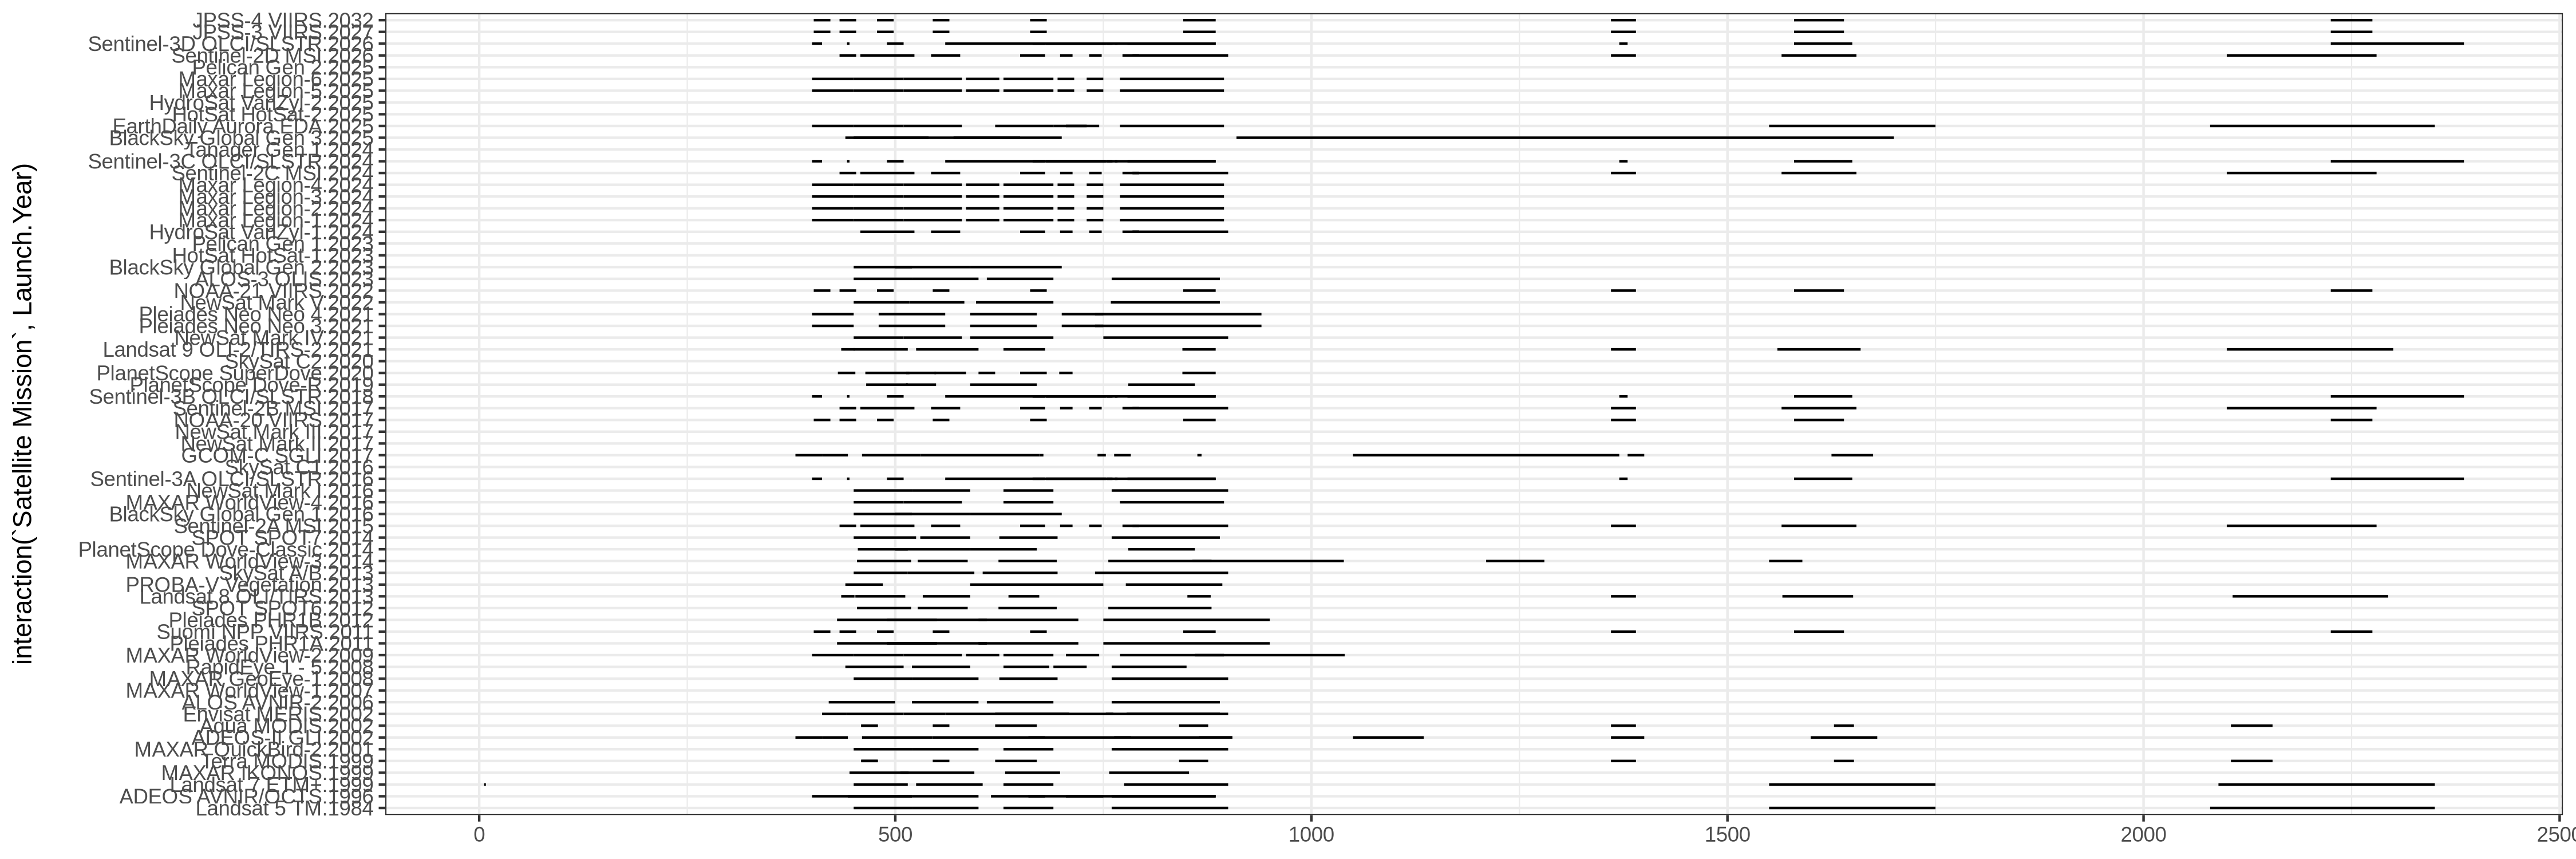

In [200]:
options(repr.plot.width =15, repr.plot.height = 5, repr.plot.res = 300)

ggplot(df_m_final_clean %>% filter(band != 'Pan') 
       #%>% filter(Affiliation == 'Planet Labs')
      ) +
    geom_linerange(aes(xmin=value_min, xmax=value_max, y=interaction(`Satellite Mission`,Launch.Year), group=`Affiliation`)) +
    #facet_wrap(~Parent.Company, scales='free_y', ncol=1) +
    theme_bw()

In [201]:
levels(df_m_final_clean$band)

[1] "Blue"       "Blue2"      "Coastal"    "Green1"     "Green2"    
 [6] "NIR"        "NIR2"       "Pan"        "Red"        "RedEdge"   
[11] "RedEdge1"   "RedEdge2"   "SWIR1"      "SWIR2"      "SWIRCirrus"
[16] "Yellow"

In [202]:
# band_colors <- c(
#         "Pan" = 'grey',
#         "Coastal" = 'purple', 
#         "Blue" = "#0066CC",      # Blue color
#         "BlueII" = "#0066CC",      # Blue color
#         "GreenI" = "#00AA44",     # Green color  
#         "GreenII" = "#00AA44",     # Green color 
#         "Yellow" = 'gold',
#         "Red" = "red",       # Red color
#         "RedEdgeI" = "indianred",       # Red color
#         "NIR" = "#8B4513",       # Brown for Near-Infrared
#         "SWIR1" = "darkred" ,      # Orange for Short-Wave Infrared (if you have it)
#         "SWIR2" = "brown"       # Orange for Short-Wave Infrared (if you have it)
# )
# Logical ordering from shortest to longest wavelength
band_order <- c(
  'Pan',         # ~450-800 nm (panchromatic - broad spectrum)
  'Coastal',     # ~400-450 nm (coastal/aerosol)
  'Blue',        # ~450-495 nm
  'Blue2',       # ~450-515 nm (extended blue)
  'Green1',      # ~495-570 nm
  'Green2',      # ~510-580 nm (extended green)
  'Yellow',      # ~570-590 nm
  'Red',         # ~620-750 nm
  'RedEdge',     # ~698-713 nm
  'RedEdge1',    # ~698-713 nm
  'RedEdge2',    # ~733-748 nm
  'NIR',         # ~750-900 nm
  'NIR2',        # ~845-885 nm (extended NIR)
  'SWIRCirrus',  # ~1360-1390 nm (cirrus detection)
  'SWIR1',       # ~1550-1750 nm
  'SWIR2',       # ~2080-2350 nm
  'TIRLWIR1',    # ~8-14 µm (thermal infrared - longwave)
  'TIRLWIR2'     # ~10.5-12.5 µm (thermal infrared - longwave)
)

# Create named color vector
band_colors <- c(
  'Pan' = '#808080',          # Gray (panchromatic covers broad spectrum)
  'Coastal' = '#4B0082',      # Indigo (shorter than visible)
  'Blue' = '#0000FF',         # Pure blue
  'Blue2' = '#1E90FF',        # Dodger blue (lighter blue)
  'Green1' = '#00FF00',       # Pure green
  'Green2' = '#32CD32',       # Lime green (slightly different green)
  'Yellow' = '#fee08b',       # Pure yellow = '#FFFF00'
  'Red' = '#FF0000',          # Pure red
  'RedEdge' = '#FF4500',      # Orange red (red-edge transition)
  'RedEdge1' = '#FF6347',     # Tomato (first red edge)
  'RedEdge2' = '#DC143C',     # Crimson (second red edge)
  'NIR' = '#8B4513',          # Saddle brown (near-infrared)
  'NIR2' = '#A0522D',         # Sienna (extended NIR)
  'SWIRCirrus' = '#D2691E',   # Peru (cirrus detection band)
  'SWIR1' = '#654321',        # Dark brown (short-wave infrared)
  'SWIR2' = '#8B4513',        # Brown (longer SWIR)
  'TIRLWIR1' = '#FF1493',     # Deep pink (thermal infrared - hot)
  'TIRLWIR2' = '#FF69B4'      # Hot pink (thermal infrared - slightly cooler)
)

Warning message in geom_linerange(aes(ymin = value_min, ymax = value_max), width = 0.1, :
“Ignoring unknown parameters: `width`”
Warning message:
“Removed 57 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 43 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 84 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 64 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 35 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 7 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 116 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 134 rows containing missing values or va

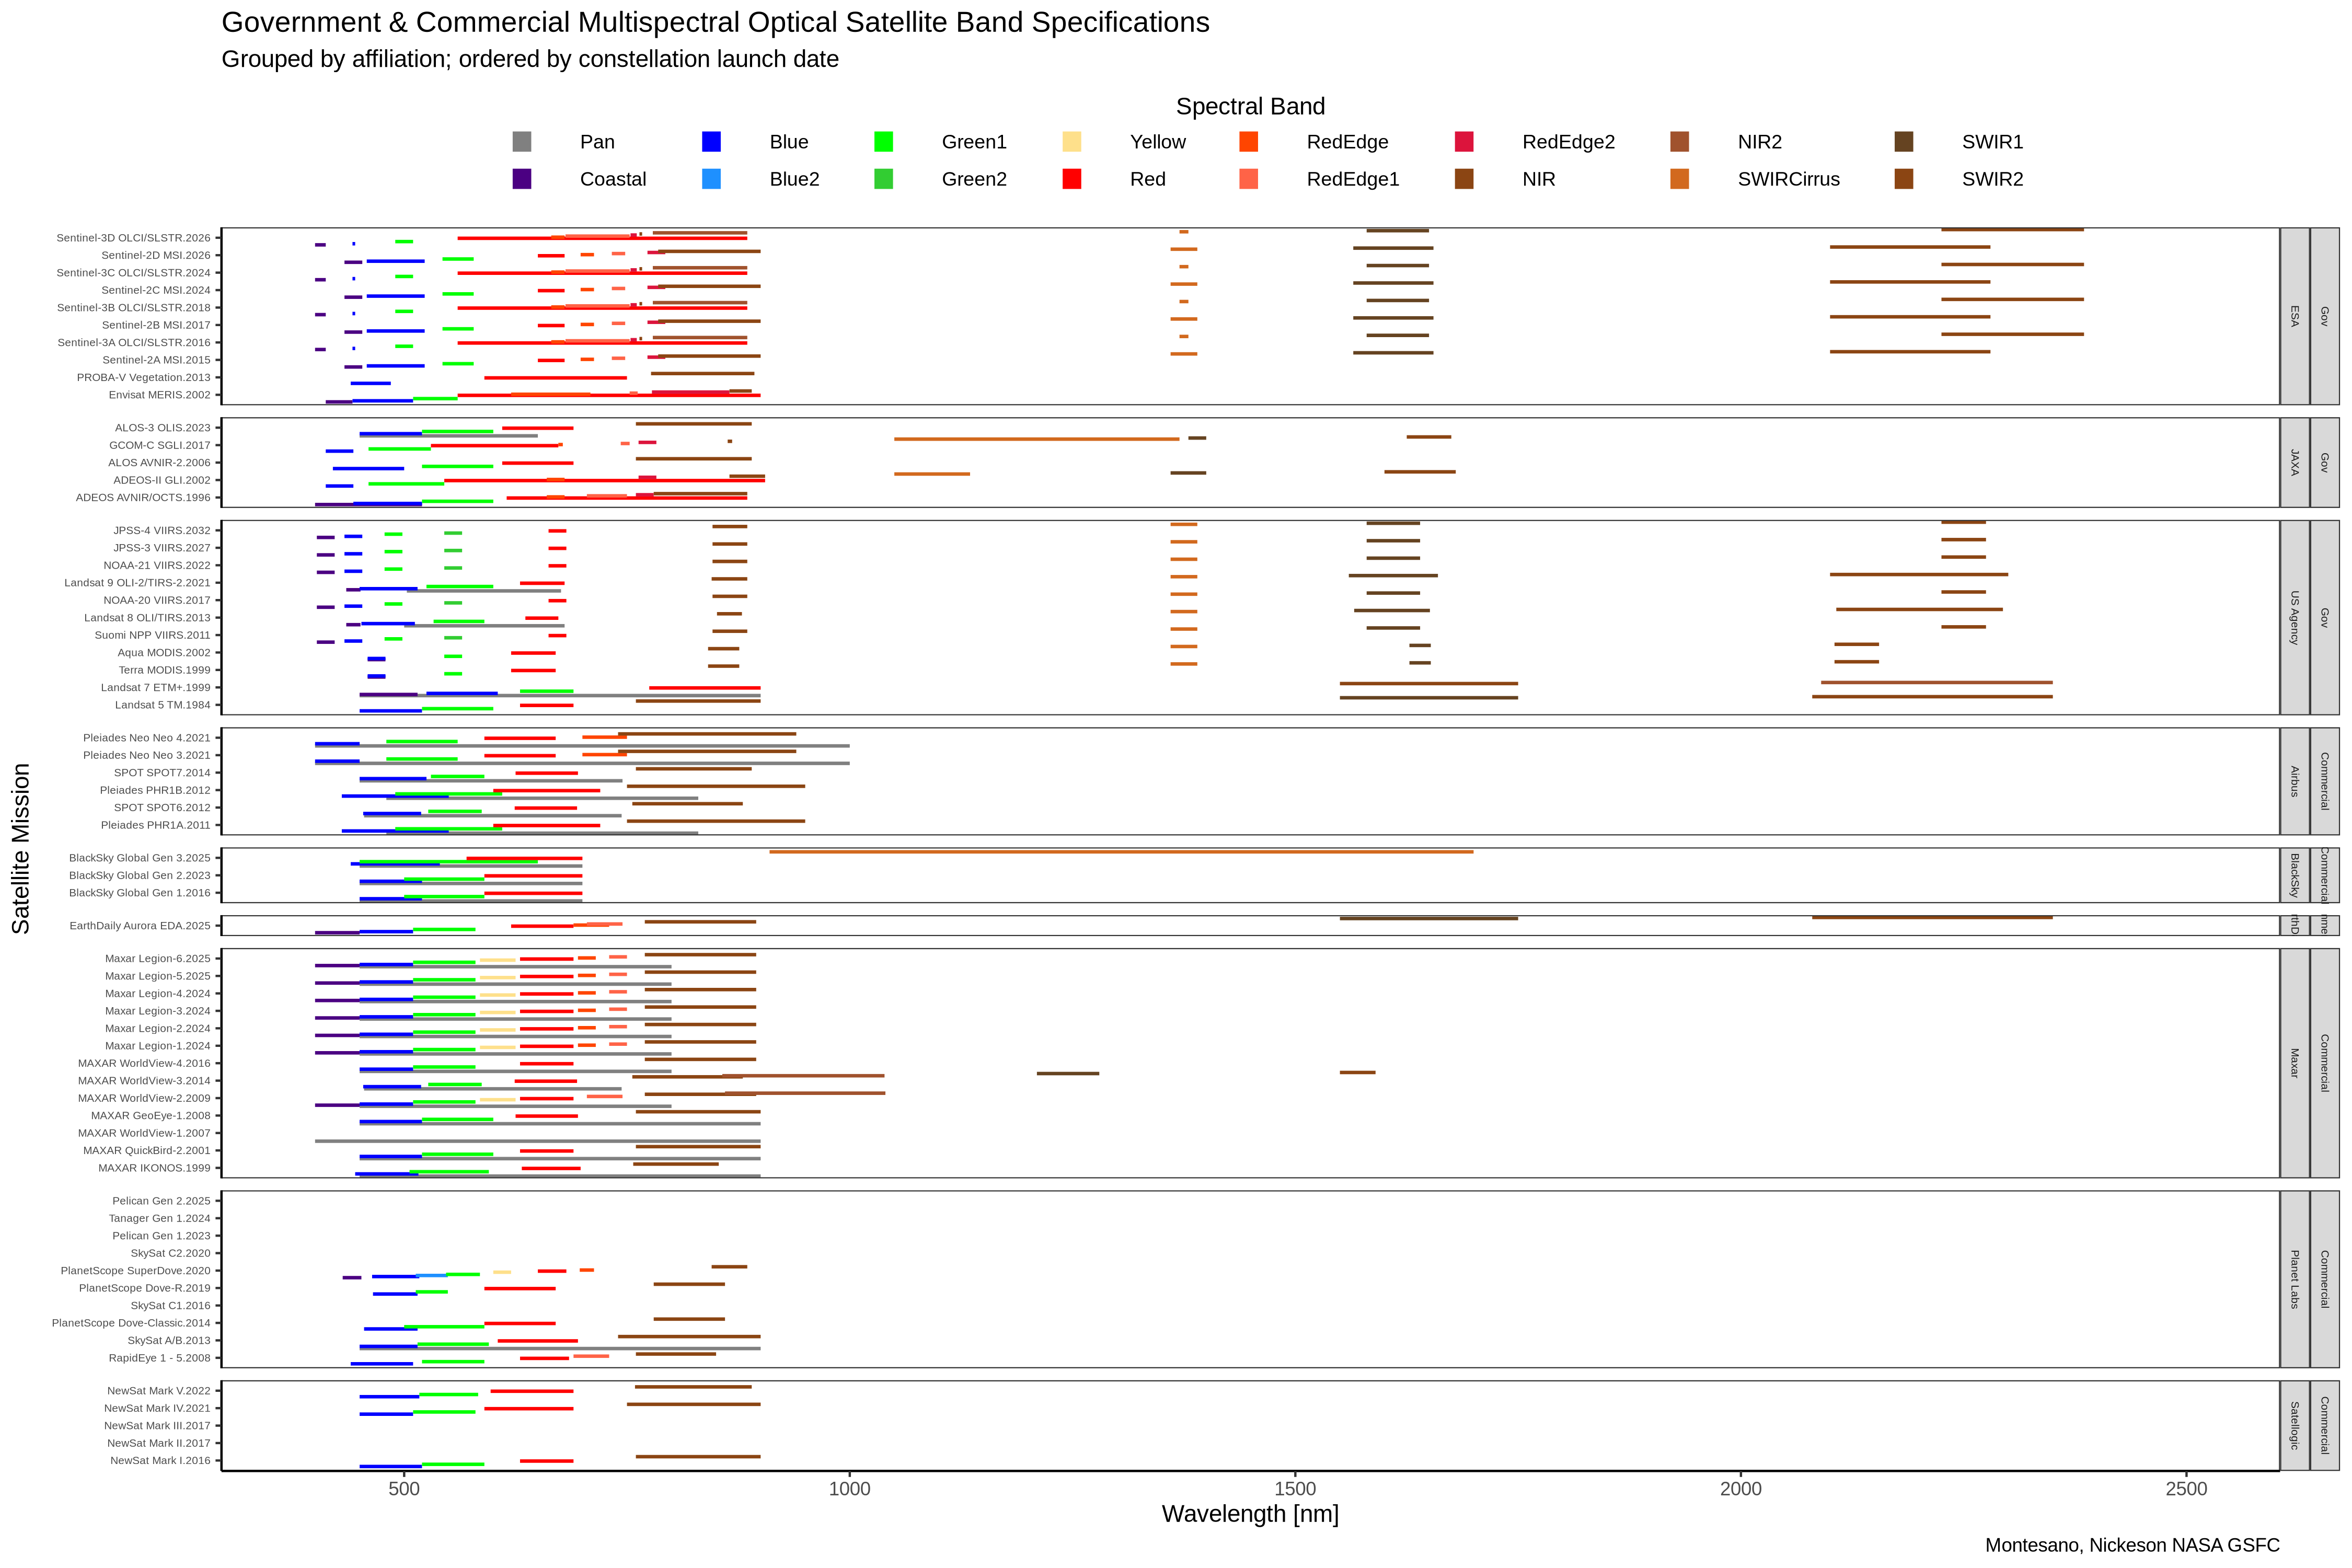

In [203]:
options(repr.plot.width =15, repr.plot.height = 10, repr.plot.res = 300)

#band_order <- c('Pan','Coastal','Blue','Blue2','Green1','Green2','Yellow','Red','RedEdge','RedEdge1','RedEdge2','NIR','NIR2','SWIR1','SWIR2','SWIRCirrus')

df_tmp = df_m_final_clean %>% 
    #filter(Affiliation == 'Planet Labs' | Affiliation == 'ESA') %>%
    filter(!(Affiliation %in% c( 'SatVu', 'HydroSat'))) %>%
      mutate(Launch.Date = as.Date(Launch.Date)) %>%  # Adjust date function as needed
      arrange(Launch.Date) %>%
      mutate(`Satellite Mission` = factor(`Satellite Mission`, levels = unique(`Satellite Mission`))) %>%
      mutate(Sector = case_when(
        Sector == "Government" ~ "Gov",
        Sector == "Commercial" ~ "Commercial",
        TRUE ~ Sector
      )) %>%
    mutate(band = factor(band, levels = band_order)) %>%
    mutate(Sector = factor(Sector, levels = c("Gov","Commercial")))

p_spectral = ggplot(df_tmp
       , aes(x = interaction(`Satellite Mission`,Launch.Year), color = band)
      ) +
    geom_linerange(aes(ymin = value_min, ymax = value_max), 
            width = 0.1, size = 0.75,
            position = position_dodge(width=1)) +
    scale_color_manual(values = band_colors) + 
    labs(title = "Government & Commercial Multispectral Optical Satellite Band Specifications",
       subtitle = "Grouped by affiliation; ordered by constellation launch date",
       x = "Satellite Mission",
       y = "Wavelength [nm]",
       color = "Spectral Band",
        caption = CAPTION_TEXT) +
    theme_bw() +
    ylim(c(400,2500))+
    coord_flip() + 
    theme(
        axis.text.x = element_text(angle = 0, hjust = 0.5), 
        axis.text.y = element_text(angle = 0, hjust = 1, size=5), 
        legend.position = "top",
        strip.text = element_text(size=5),
        panel.grid = element_blank(),
        panel.background = element_blank(),
        axis.line = element_line(color = "black")
    ) +
    guides(
        color = guide_legend(
          title.position = "top",
          title.hjust = 0.5,
          label.position = "right",
          ncol = 8,
          nrow = 2,
          byrow = FALSE,
          keywidth = unit(1.5, "cm"),    # Wider for horizontal lines
          keyheight = unit(0.3, "cm"),   # Shorter for horizontal lines
          label.theme = element_text(size = 9),
          override.aes = list(
            size = .1,                     # Line thickness
            linewidth = 4,                # Alternative line thickness
            linetype = 1                  # Solid line
          )
        )
    ) +
    facet_grid(Sector + Affiliation ~ ., scales = "free", space = "free")
p_spectral

In [42]:
ggsave(filename = '/projects/my-private-bucket/databank/csda/vhr_spectral_bands.png',plot = p_spectral, width = 10, height = 9, dpi=300 )

Warning message:
“Removed 57 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 166 rows containing missing values or values outside the scale range
(`geom_segment()`).”
